In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin-sindy')

import utils.preprocess as pp
from analyze_feats import get_scaled_traj

In [11]:
path_to_bf = "//allen/aics/assay-dev/users/Benji/CurrentProjects/im2im_dev/cyto-dl/logs/eval/runs/endo_time/mae_bf/2024-08-14_10-19-11/predictions.csv"
savedir = "//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/"

# Load and preprocess data
df = pd.read_csv(path_to_bf)

# add crop location index as metadata
num_loc = 54
num_T = 577
loc_idx = np.tile(np.arange(0, num_loc), num_T)

# get array of MAE features
X_feats = pp.get_array(df,metadata_col=['crop_index','T'])
# z-score
X_scaled = pp.scale_features(X_feats)

# build dataframe of scaled data, leaving out crop path metadata
data_scaled = np.hstack((X_scaled,df['T'].values[:,None],df['crop_index'].values[:,None]))
cols = df.columns
df_scaled = pd.DataFrame(data_scaled,columns=cols)
df_scaled['crop_index'] = df_scaled['crop_index'].astype(int)
df_scaled['T'] = df_scaled['T'].astype(int)

# full PCA: get singular values, explained variance ratio, and principal components
svs, exp_var, pcs = pp.get_PCA(X_scaled)

# find number of PCs to explain 95% of variance
cumul_var = np.cumsum(exp_var)
num_modes_95 = np.where(cumul_var > 0.95)[0].min()

# get array of (scaled) single crop trajectories projected onto these top PC modes
X_t = pp.project_trajectories(df_scaled, pcs[:num_modes_95], 'crop_index', metadata_col=['crop_index','T'])

# split into high and low flow trajectories
t_change = (24*60 - 25)//5 # time point (index) at which to change from high to low flow occurs (25 minutes before 24 hours)
X_t_high = X_t[:,:t_change,:] # high flow trajectories
X_t_low = X_t[:,t_change:,:] # low flow trajectories

# save trajectory data as .npy files to load for analyses
np.save('../data/bf_95pctVarPCs_highFlow',X_t_high)
np.save('../data/bf_95pctVarPCs_lowFlow',X_t_low)
np.save('../data/bf_95pctVarPCs_all',X_t)


Number of modes to explain 95% of variance:  20


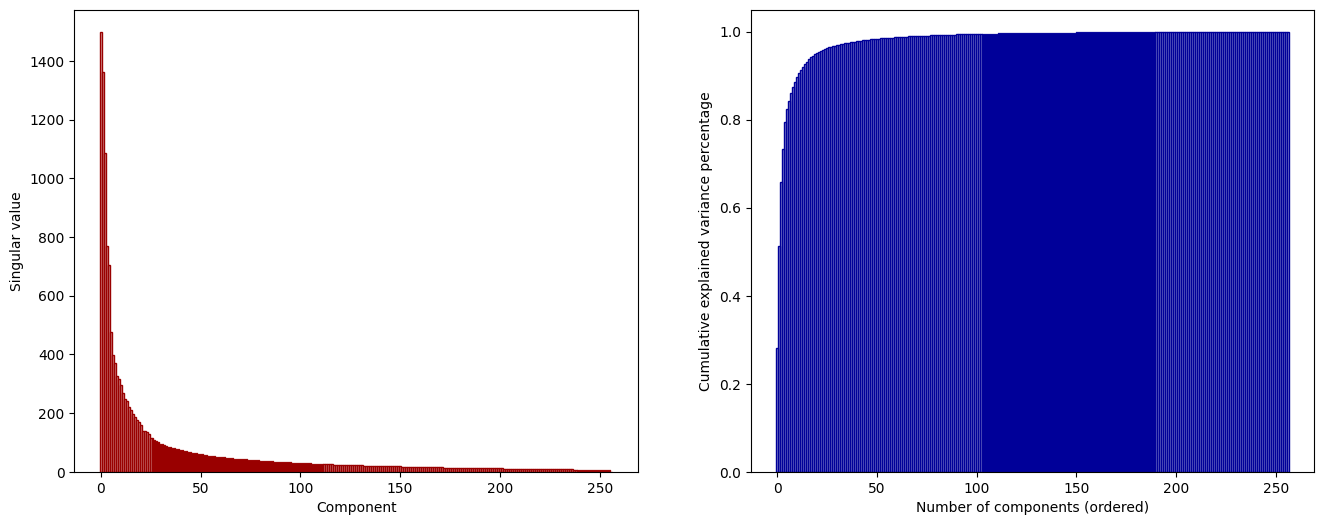

In [12]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
m=len(svs)
ax[0].bar(np.arange(m),svs, color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(m),np.cumsum(exp_var),color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Text(0, 0.5, 'Cumulative explained variance percentage')

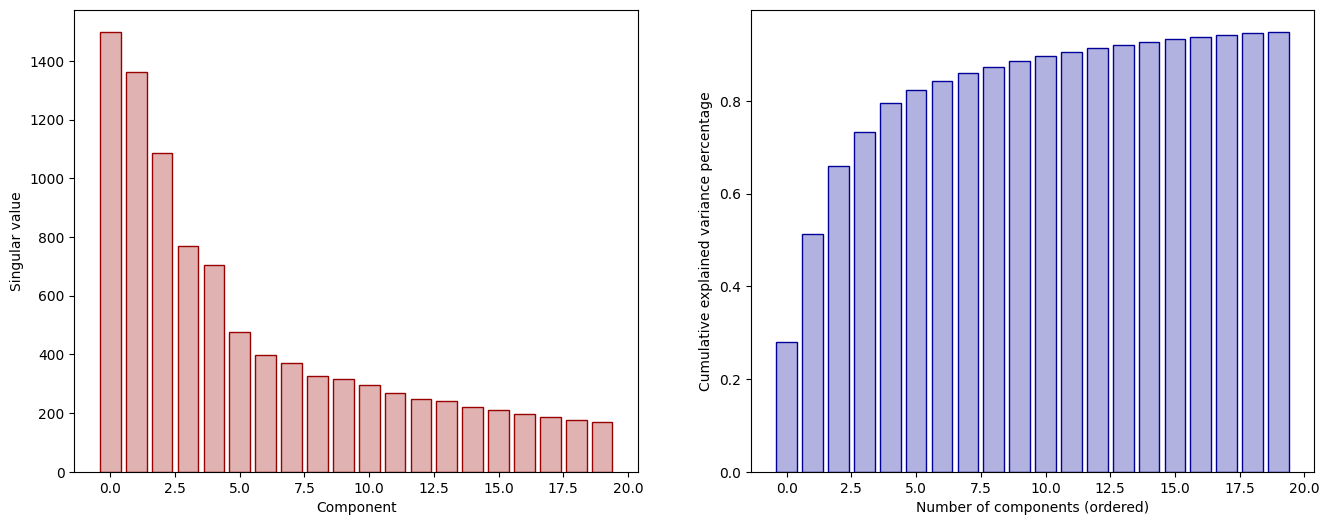

In [13]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(num_modes_95),svs[:num_modes_95], color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(num_modes_95),np.cumsum(exp_var)[:num_modes_95],color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

In [14]:
X_t = np.load('../data/bf_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array
X_pca = X_t.reshape((-1,num_modes_95))[:,:2] # truncated to top 2 modes

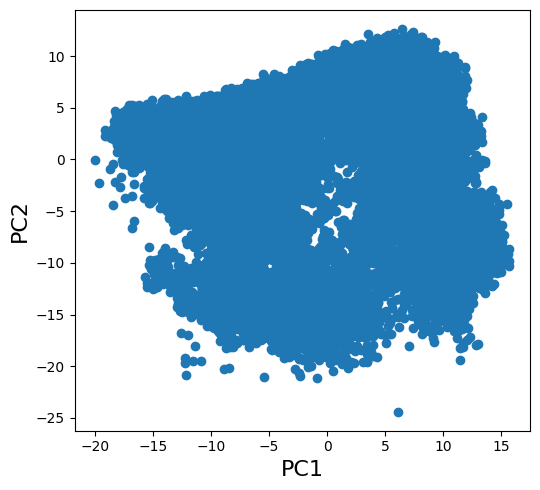

In [15]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))
sc_plt = ax.scatter(X_pca[:,0], X_pca[:,1]) 
ax.set_xlabel("PC1", fontsize=16)
ax.set_ylabel("PC2", fontsize=16)
plt.tight_layout()

In [17]:
X_t_high = np.load('../data/bf_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/bf_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

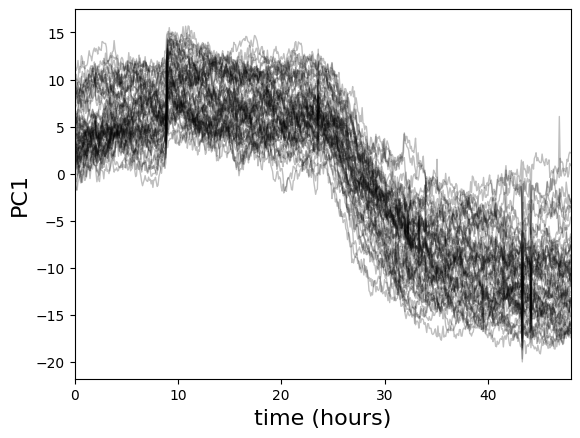

In [19]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
#plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

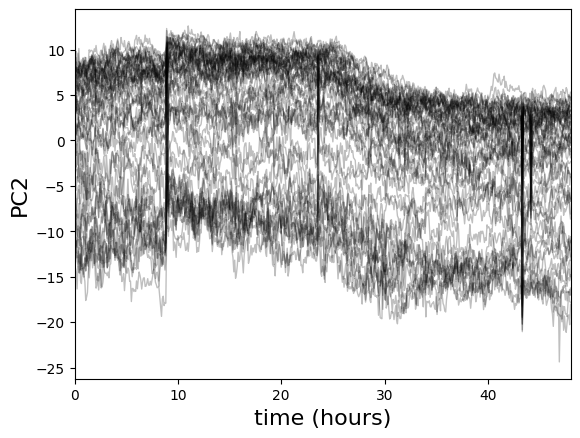

In [22]:
# plot PCA mode m vs time for each location at high flow
m=2

for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,m-1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC"+str(m), fontsize=16)

Text(0, 0.5, 'PC2')

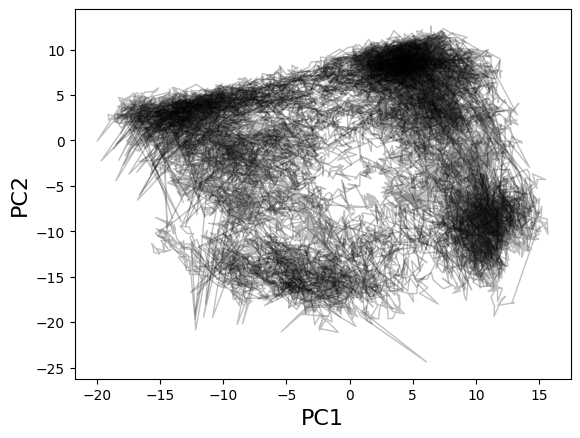

In [21]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)